Epoch 50, MSE Loss: 0.2196
Epoch 100, MSE Loss: 0.0680
Epoch 150, MSE Loss: 0.0743
Epoch 200, MSE Loss: 0.0472
Epoch 250, MSE Loss: 0.0701
Epoch 300, MSE Loss: 0.0642
Epoch 350, MSE Loss: 0.0469
Epoch 400, MSE Loss: 0.0514
Epoch 450, MSE Loss: 0.0450
Epoch 500, MSE Loss: 0.0296


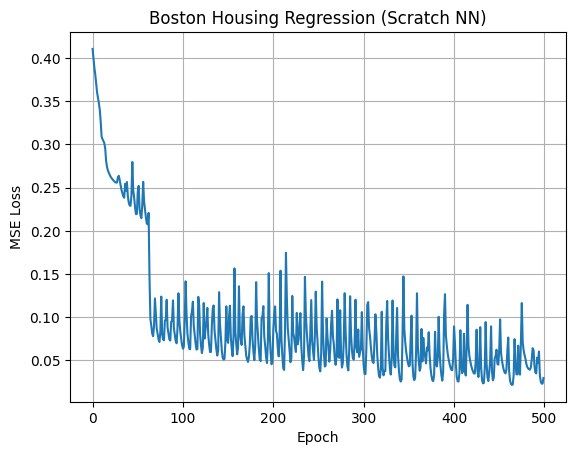

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load Boston dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
X = boston.data.values
y = boston.target.values.astype(float).reshape(-1,1)

# Normalize
X = StandardScaler().fit_transform(X)
y = MinMaxScaler().fit_transform(y)

# Activations
def relu(x): return np.maximum(0,x)
def relu_deriv(x): return (x>0).astype(float)
def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(x):
    s = sigmoid(x)
    return s*(1-s)

# Init
W1 = np.random.randn(13,64)
W2 = np.random.randn(64,1)
lr = 0.01

loss_list = []

# Training
for epoch in range(1,501):
    z1 = X @ W1
    a1 = relu(z1)
    z2 = a1 @ W2
    y_pred = sigmoid(z2)

    loss = np.mean((y - y_pred)**2)
    loss_list.append(loss)

    dz2 = (y_pred - y) * sigmoid_deriv(z2)
    dW2 = a1.T @ dz2
    dz1 = dz2 @ W2.T * relu_deriv(z1)
    dW1 = X.T @ dz1

    W1 -= lr*dW1
    W2 -= lr*dW2

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {loss:.4f}")

# Plot
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Boston Housing Regression (Scratch NN)")
plt.grid(True)
plt.show()


Epoch 1, Loss: 17.5816, Accuracy: 0.1256
Epoch 2, Loss: 18.7027, Accuracy: 0.0975
Epoch 3, Loss: 10.1302, Accuracy: 0.1214
Epoch 4, Loss: 2.3118, Accuracy: 0.0986
Epoch 5, Loss: 2.3026, Accuracy: 0.0986
Epoch 6, Loss: 2.3026, Accuracy: 0.0986
Epoch 7, Loss: 2.3026, Accuracy: 0.0986
Epoch 8, Loss: 2.3026, Accuracy: 0.0986
Epoch 9, Loss: 2.3026, Accuracy: 0.0986
Epoch 10, Loss: 2.3026, Accuracy: 0.0986
Epoch 11, Loss: 2.3026, Accuracy: 0.0986
Epoch 12, Loss: 2.3026, Accuracy: 0.0986
Epoch 13, Loss: 2.3026, Accuracy: 0.0986
Epoch 14, Loss: 2.3026, Accuracy: 0.0986
Epoch 15, Loss: 2.3026, Accuracy: 0.0986
Epoch 16, Loss: 2.3026, Accuracy: 0.0986
Epoch 17, Loss: 2.3026, Accuracy: 0.0986
Epoch 18, Loss: 2.3026, Accuracy: 0.0986
Epoch 19, Loss: 2.3026, Accuracy: 0.0986
Epoch 20, Loss: 2.3026, Accuracy: 0.0986


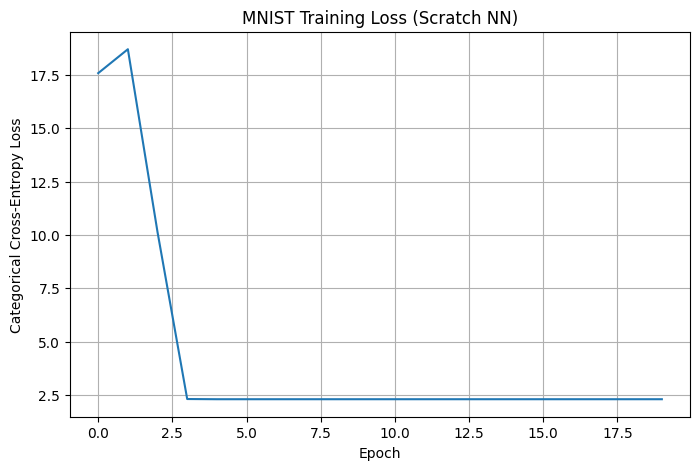

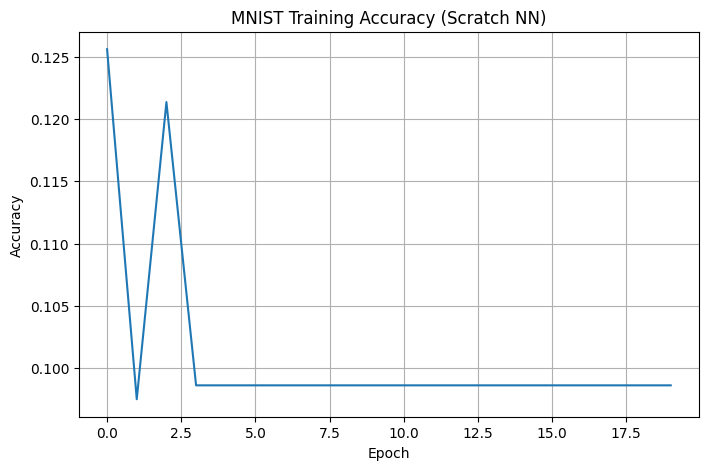

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder

# Activations
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

# Load MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True)

# Convert DataFrame to NumPy
X = X.to_numpy()

# Normalize
X = X / 255.0

# One-hot
enc = OneHotEncoder(sparse_output=False)
y = enc.fit_transform(y.values.reshape(-1,1))

# Weights
W1 = np.random.randn(784, 128)
W2 = np.random.randn(128, 10)
lr = 0.01

loss_list = []
acc_list = []

# Training
for epoch in range(1, 21):
    z1 = X @ W1
    a1 = relu(z1)
    z2 = a1 @ W2
    y_pred = softmax(z2)

    loss = -np.mean(np.sum(y * np.log(y_pred + 1e-9), axis=1))
    loss_list.append(loss)

    dz2 = y_pred - y
    dW2 = a1.T @ dz2
    dz1 = dz2 @ W2.T * relu_deriv(z1)
    dW1 = X.T @ dz1

    W1 -= lr * dW1
    W2 -= lr * dW2

    acc = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y, axis=1))
    acc_list.append(acc)

    print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# --------- PLOTS ---------

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("MNIST Training Loss (Scratch NN)")
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(acc_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Training Accuracy (Scratch NN)")
plt.grid(True)
plt.show()


C:\Users\arjun\AppData\Local\Temp\ipykernel_12920\2154048247.py:30: RuntimeWarning: divide by zero encountered in log
  loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
C:\Users\arjun\AppData\Local\Temp\ipykernel_12920\2154048247.py:30: RuntimeWarning: invalid value encountered in multiply
  loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
C:\Users\arjun\AppData\Local\Temp\ipykernel_12920\2154048247.py:15: RuntimeWarning: overflow encountered in exp
  def sigmoid(x): return 1/(1+np.exp(-x))


Epoch 100, Loss: nan, Accuracy: 0.6510
Epoch 200, Loss: nan, Accuracy: 0.6510
Epoch 300, Loss: nan, Accuracy: 0.6055
Epoch 400, Loss: nan, Accuracy: 0.6510
Epoch 500, Loss: nan, Accuracy: 0.6510
Epoch 600, Loss: nan, Accuracy: 0.2396
Epoch 700, Loss: nan, Accuracy: 0.2161
Epoch 800, Loss: nan, Accuracy: 0.6510
Epoch 900, Loss: nan, Accuracy: 0.6510
Epoch 1000, Loss: nan, Accuracy: 0.6510


C:\Users\arjun\AppData\Local\Temp\ipykernel_12920\2154048247.py:27: RuntimeWarning: overflow encountered in matmul
  z2 = a1 @ W2
C:\Users\arjun\AppData\Local\Temp\ipykernel_12920\2154048247.py:27: RuntimeWarning: invalid value encountered in matmul
  z2 = a1 @ W2


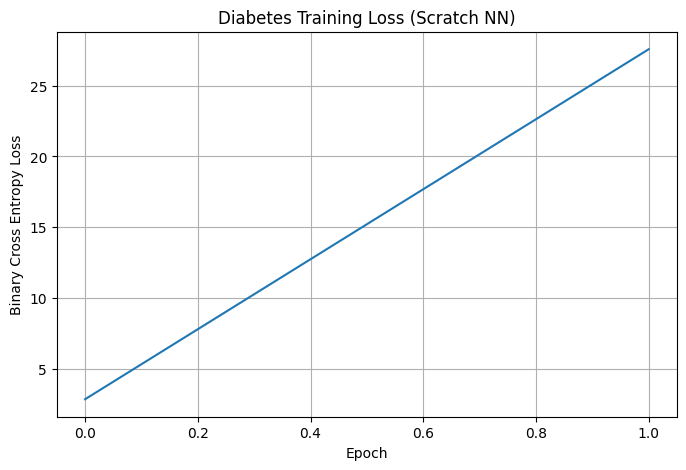

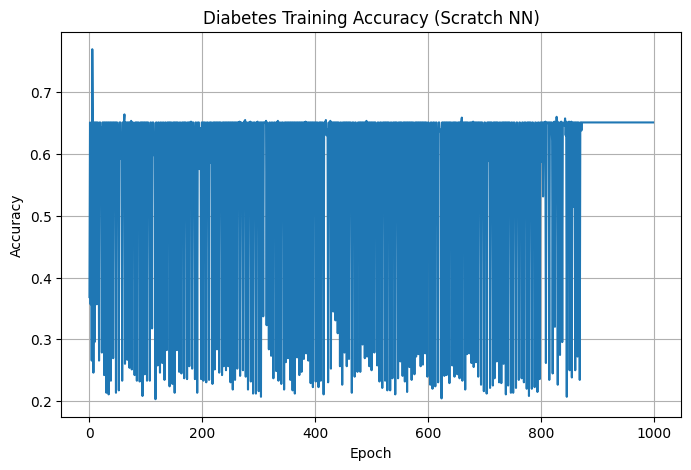

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values.reshape(-1,1)

# Normalize input features (IMPORTANT)
X = StandardScaler().fit_transform(X)

def relu(x): return np.maximum(0,x)
def relu_deriv(x): return (x>0).astype(float)
def sigmoid(x): return 1/(1+np.exp(-x))

W1 = np.random.randn(8,16)
W2 = np.random.randn(16,1)
lr = 0.01

loss_list = []
acc_list = []

for epoch in range(1,1001):
    z1 = X @ W1
    a1 = relu(z1)
    z2 = a1 @ W2
    y_pred = sigmoid(z2)

    loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
    loss_list.append(loss)

    dz2 = y_pred - y
    dW2 = a1.T @ dz2
    dz1 = dz2 @ W2.T * relu_deriv(z1)
    dW1 = X.T @ dz1

    W1 -= lr*dW1
    W2 -= lr*dW2

    acc = np.mean((y_pred>0.5)==y)
    acc_list.append(acc)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# --------- PLOTS ---------

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Diabetes Training Loss (Scratch NN)")
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(acc_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Diabetes Training Accuracy (Scratch NN)")
plt.grid(True)
plt.show()


Epoch 1/50


C:\Users\arjun\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0648 - mae: 0.2069  
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0274 - mae: 0.1322 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 - mae: 0.0964 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0140 - mae: 0.0776 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - mae: 0.0705 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0105 - mae: 0.0674 
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0097 - mae: 0.0642 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0091 - mae: 0.0630 
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - mae: 0.0614 
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083 - mae: 0.0591 
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - mae: 0.0585 
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - mae: 0.0580 
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

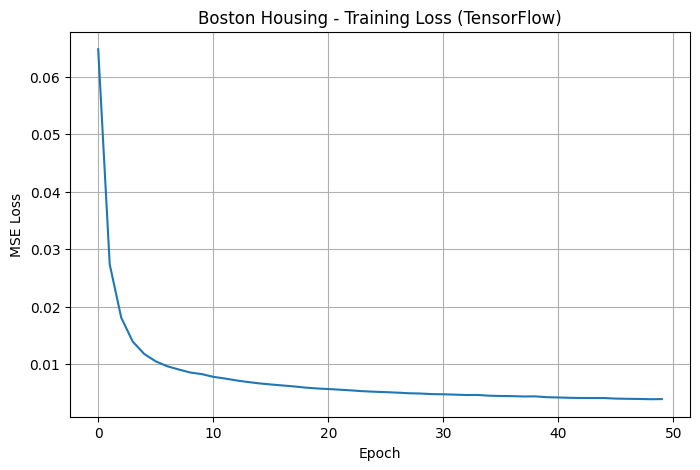

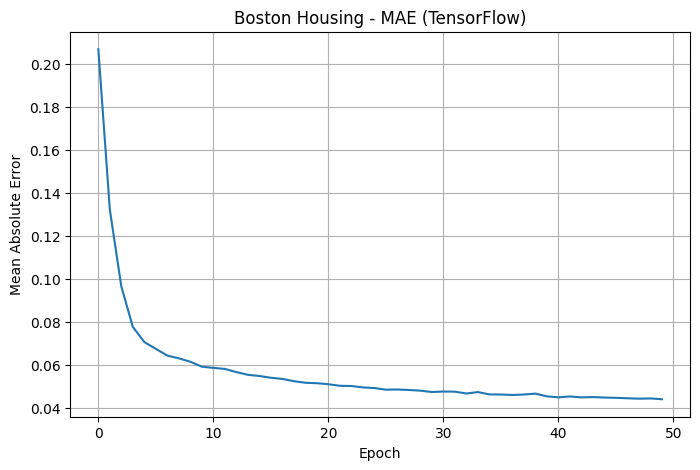

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load Boston dataset from OpenML
boston = fetch_openml(name="boston", version=1, as_frame=True)
X = boston.data.values
y = boston.target.values.astype(float).reshape(-1,1)

# Normalize
X = StandardScaler().fit_transform(X)
y = MinMaxScaler().fit_transform(y)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = model.fit(X, y, epochs=50, verbose=1)

# -------- PLOTS --------

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Boston Housing - Training Loss (TensorFlow)")
plt.grid(True)
plt.show()

# MAE plot
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'])
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("Boston Housing - MAE (TensorFlow)")
plt.grid(True)
plt.show()


Epoch 1, Loss: 16.9962, Acc: 0.1591
Epoch 2, Loss: 16.9627, Acc: 0.1606
Epoch 3, Loss: 16.9284, Acc: 0.1621
Epoch 4, Loss: 16.8940, Acc: 0.1632
Epoch 5, Loss: 16.8597, Acc: 0.1651
Epoch 6, Loss: 16.8259, Acc: 0.1665
Epoch 7, Loss: 16.7924, Acc: 0.1680
Epoch 8, Loss: 16.7588, Acc: 0.1692
Epoch 9, Loss: 16.7258, Acc: 0.1709
Epoch 10, Loss: 16.6944, Acc: 0.1728
Epoch 11, Loss: 16.6649, Acc: 0.1743
Epoch 12, Loss: 16.6365, Acc: 0.1755
Epoch 13, Loss: 16.6085, Acc: 0.1771
Epoch 14, Loss: 16.5806, Acc: 0.1785
Epoch 15, Loss: 16.5529, Acc: 0.1797
Epoch 16, Loss: 16.5254, Acc: 0.1808
Epoch 17, Loss: 16.4985, Acc: 0.1820
Epoch 18, Loss: 16.4720, Acc: 0.1835
Epoch 19, Loss: 16.4458, Acc: 0.1846
Epoch 20, Loss: 16.4195, Acc: 0.1854


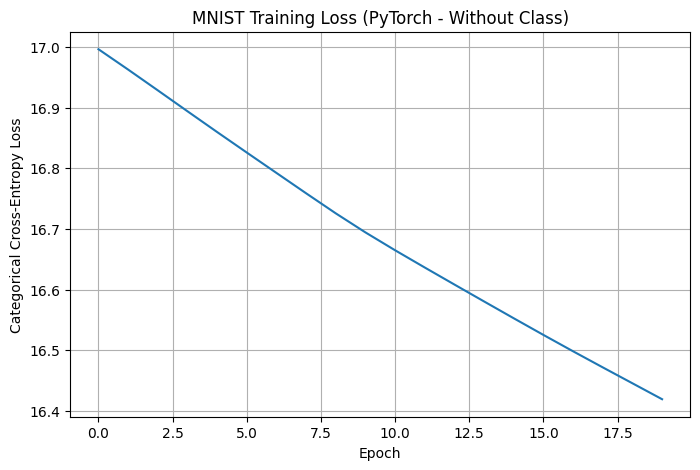

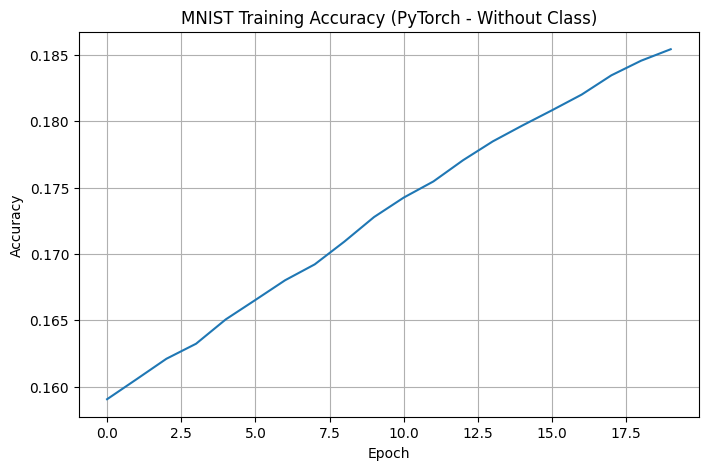

In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

mnist = datasets.MNIST('.', train=True, download=True,
                       transform=transforms.ToTensor())

X = mnist.data.reshape(-1,784).float()/255
y = torch.nn.functional.one_hot(mnist.targets,10).float()

W1 = torch.randn(784,128, requires_grad=True)
W2 = torch.randn(128,10, requires_grad=True)

loss_list = []
acc_list = []

for epoch in range(20):
    z1 = torch.relu(X @ W1)
    y_pred = torch.softmax(z1 @ W2, dim=1)

    loss = -torch.mean(torch.sum(y*torch.log(y_pred+1e-9),dim=1))
    loss.backward()

    with torch.no_grad():
        W1 -= 0.01*W1.grad
        W2 -= 0.01*W2.grad
        W1.grad.zero_()
        W2.grad.zero_()

    acc = (torch.argmax(y_pred,1)==torch.argmax(y,1)).float().mean()
    
    loss_list.append(loss.item())
    acc_list.append(acc.item())
    
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Acc: {acc:.4f}")

# --------- PLOTS ---------

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("MNIST Training Loss (PyTorch - Without Class)")
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(acc_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Training Accuracy (PyTorch - Without Class)")
plt.grid(True)
plt.show()


In [9]:
import torch
import torch.nn as nn
import pandas as pd

df = pd.read_csv("diabetes.csv")
X = torch.tensor(df.iloc[:,:-1].values, dtype=torch.float32)
y = torch.tensor(df.iloc[:,-1].values, dtype=torch.float32).reshape(-1,1)

class DiabetesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8,16)
        self.fc2 = nn.Linear(16,1)

    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = DiabetesNet()
loss_fn = nn.BCELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 100 == 0:
        acc = ((y_pred>0.5)==y).float().mean()
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")


Epoch 0, Loss: 4.2380, Accuracy: 0.3490
Epoch 100, Loss: 0.4556, Accuracy: 0.8008
Epoch 200, Loss: 0.4236, Accuracy: 0.8268
Epoch 300, Loss: 0.3934, Accuracy: 0.8464
Epoch 400, Loss: 0.3642, Accuracy: 0.8594
Epoch 500, Loss: 0.3419, Accuracy: 0.8555
Epoch 600, Loss: 0.3295, Accuracy: 0.8724
Epoch 700, Loss: 0.3125, Accuracy: 0.8607
Epoch 800, Loss: 0.3006, Accuracy: 0.8659
Epoch 900, Loss: 0.3035, Accuracy: 0.8841
